# 개인별 적합도 산출 노트북
**확정 공식**
```
Fit(사람, 과제) = Σ [ 레벨(s) × 스킬중요도(s) ] × (1 + 0.5 × 과제난이도_norm(p))
스킬중요도(s) = 1 + I_idf(s) × IDF_norm(s) + I_kss(s) × KSS_norm(s)
```
- w1 = 1 (희귀도), w2 = 1 (수요집중도), w3 = 0.5 (과제 난이도)
- I_idf, I_kss : 카드 1/2에서 사용자가 선택한 스킬이면 1, 아니면 0

## 0. 라이브러리 임포트

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ipywidgets as widgets
from IPython.display import display, clear_output
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
print('라이브러리 로드 완료')

라이브러리 로드 완료


## 1. 데이터 로드

In [2]:
# ── 파일 경로 (코드와 같은 폴더에 위치) ──────────────────────────────────
HR_FILE     = 'RND_HR_DB.xlsx'
SKILL_FILE  = 'Project_Required_Skills_Matrix.xlsx'

# ── 인사 DB ───────────────────────────────────────────────────────────────
df_hr    = pd.read_excel(HR_FILE, sheet_name='인사_DB')
df_skill = pd.read_excel(HR_FILE, sheet_name='R&D_역량_점수')

# ── 과제-스킬 매트릭스 ────────────────────────────────────────────────────
df_matrix = pd.read_excel(SKILL_FILE, sheet_name='역량_요구_매트릭스')

print(f'인사 DB     : {len(df_hr)}명')
print(f'역량 점수   : {len(df_skill)}행 ({df_skill["사번"].nunique()}명)')
print(f'스킬 종류   : {df_skill["요소기술"].nunique()}개')
print(f'과제 수     : {df_matrix.shape[1] - 1}개')

인사 DB     : 500명
역량 점수   : 7125행 (500명)
스킬 종류   : 88개
과제 수     : 20개


## 2. 전처리

In [3]:
# ── 2-1. 스킬 wide matrix (사람 × 스킬, 없으면 0) ─────────────────────────
df_wide = df_skill.pivot_table(
    index='사번', columns='요소기술', values='기술 레벨 (Score)', aggfunc='max'
).fillna(0)

ALL_SKILLS   = sorted(df_wide.columns.tolist())
ALL_PROJECTS = [c for c in df_matrix.columns if c != '필수 요소기술']
N_PEOPLE     = len(df_wide)

# ── 2-2. 과제-스킬 이진 매트릭스 (스킬 × 과제) ───────────────────────────
df_matrix = df_matrix.set_index('필수 요소기술')
proj_skill_bin = (df_matrix == '●').astype(int)   # 스킬 행 × 과제 열

# ── 2-3. 스킬별 보유자 수, 레벨4+ 보유자 수 ──────────────────────────────
holders     = (df_wide > 0).sum()          # 스킬별 보유자 수
holders_lv4 = (df_wide >= 4).sum()         # 스킬별 레벨4 이상 보유자 수

# ── 2-4. 스킬별 요구 과제 수 ─────────────────────────────────────────────
demand = proj_skill_bin.sum(axis=1)        # 스킬별 요구 과제 수
demand = demand.reindex(ALL_SKILLS).fillna(0)

print('전처리 완료')
print(f'  스킬 wide matrix shape : {df_wide.shape}')
print(f'  과제-스킬 매트릭스 shape: {proj_skill_bin.shape}')

전처리 완료
  스킬 wide matrix shape : (500, 88)
  과제-스킬 매트릭스 shape: (87, 20)


## 3. EDA — 카드 1 : 스킬 희귀도 (IDF)

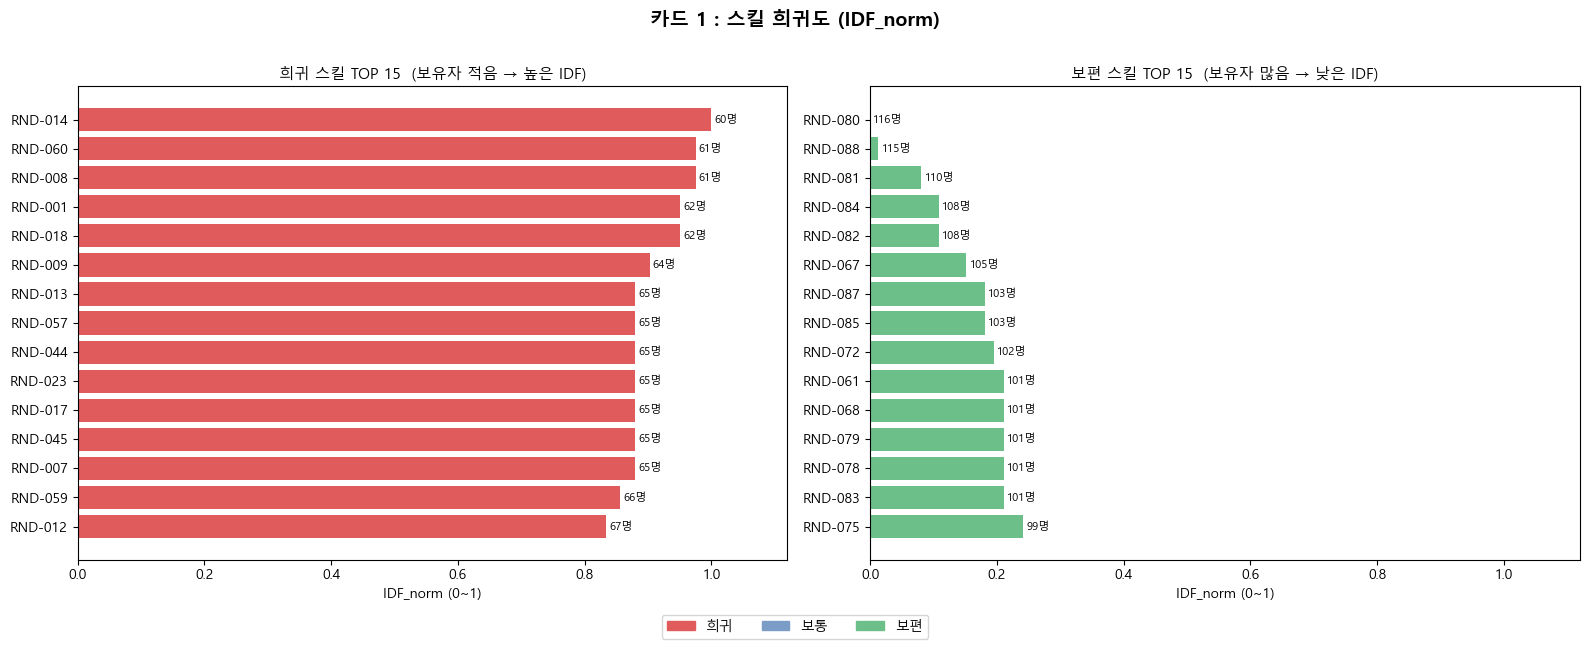


희귀(29개) | 보통(30개) | 보편(29개)


In [4]:
# ── IDF 계산 ──────────────────────────────────────────────────────────────
idf_raw  = np.log((N_PEOPLE + 1) / (holders + 1))   # +1 smoothing (보유자 0 방지)
idf_min, idf_max = idf_raw.min(), idf_raw.max()
idf_norm = (idf_raw - idf_min) / (idf_max - idf_min)

df_idf = pd.DataFrame({
    '스킬': ALL_SKILLS,
    '보유자수': holders.reindex(ALL_SKILLS).fillna(0).astype(int),
    'IDF_raw': idf_raw.reindex(ALL_SKILLS),
    'IDF_norm': idf_norm.reindex(ALL_SKILLS)
}).sort_values('IDF_norm', ascending=False).reset_index(drop=True)

# 분류 (상위 33% = 희귀, 하위 33% = 보편, 나머지 = 보통)
q67 = df_idf['IDF_norm'].quantile(0.67)
q33 = df_idf['IDF_norm'].quantile(0.33)
def classify_idf(v):
    if v >= q67: return '희귀'
    elif v <= q33: return '보편'
    else: return '보통'
df_idf['분류'] = df_idf['IDF_norm'].apply(classify_idf)

# ── 시각화 : TOP 15 희귀 / BOTTOM 15 보편 ────────────────────────────────
TOP_N = 15
top_rare   = df_idf.head(TOP_N)
top_common = df_idf.tail(TOP_N).iloc[::-1]

color_map = {'희귀': '#E05C5C', '보통': '#7A9CC6', '보편': '#6DBF8A'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('카드 1 : 스킬 희귀도 (IDF_norm)', fontsize=14, fontweight='bold', y=1.01)

for ax, df_sub, title in [
    (axes[0], top_rare,   f'희귀 스킬 TOP {TOP_N}  (보유자 적음 → 높은 IDF)'),
    (axes[1], top_common, f'보편 스킬 TOP {TOP_N}  (보유자 많음 → 낮은 IDF)'),
]:
    colors = [color_map[c] for c in df_sub['분류']]
    bars = ax.barh(df_sub['스킬'], df_sub['IDF_norm'], color=colors)
    for bar, holders_cnt in zip(bars, df_sub['보유자수']):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f'{holders_cnt}명', va='center', fontsize=8)
    ax.set_xlim(0, 1.12)
    ax.set_xlabel('IDF_norm (0~1)')
    ax.set_title(title, fontsize=11)
    ax.invert_yaxis()

patches = [mpatches.Patch(color=v, label=k) for k, v in color_map.items()]
fig.legend(handles=patches, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.show()

print(f"\n희귀({df_idf[df_idf['분류']=='희귀'].shape[0]}개) "
      f"| 보통({df_idf[df_idf['분류']=='보통'].shape[0]}개) "
      f"| 보편({df_idf[df_idf['분류']=='보편'].shape[0]}개)")

### 카드 1 선택 — 희귀도를 적합도에 반영할 스킬 체크

In [15]:
# ── 체크박스 UI ───────────────────────────────────────────────────────────
# 희귀도 내림차순으로 정렬된 스킬 목록 표시
skill_order_idf = df_idf['스킬'].tolist()

cb_idf = {}
rows_idf = []
for skill in skill_order_idf:
    row = df_idf[df_idf['스킬'] == skill].iloc[0]
    label = f"{skill}  │  IDF={row['IDF_norm']:.3f}  │  보유자={row['보유자수']}명  │  [{row['분류']}]"
    cb = widgets.Checkbox(value=False, description=label,
                          layout=widgets.Layout(width='550px'),
                          style={'description_width': 'initial'})
    cb_idf[skill] = cb
    rows_idf.append(cb)

btn_all_rare   = widgets.Button(description='희귀 전체 선택',   button_style='danger',  layout=widgets.Layout(width='140px'))
btn_all_clear  = widgets.Button(description='전체 해제',        button_style='',        layout=widgets.Layout(width='140px'))

def select_all_rare(_):
    for skill, cb in cb_idf.items():
        row = df_idf[df_idf['스킬'] == skill].iloc[0]
        cb.value = (row['분류'] == '희귀')

def clear_all_idf(_):
    for cb in cb_idf.values(): cb.value = False

btn_all_rare.on_click(select_all_rare)
btn_all_clear.on_click(clear_all_idf)

header = widgets.HTML('<b>희귀도를 적합도에 반영할 스킬을 선택하세요 (I_idf = 1)</b><br><br>')
btn_row = widgets.HBox([btn_all_rare, btn_all_clear])
scroll_box = widgets.VBox(rows_idf, layout=widgets.Layout(height='350px', overflow_y='scroll', border='1px solid #ccc', padding='6px'))

display(widgets.VBox([header, btn_row, scroll_box]))

## 4. EDA — 카드 2 : 수요-공급 불균형 & 병목 / SPOF

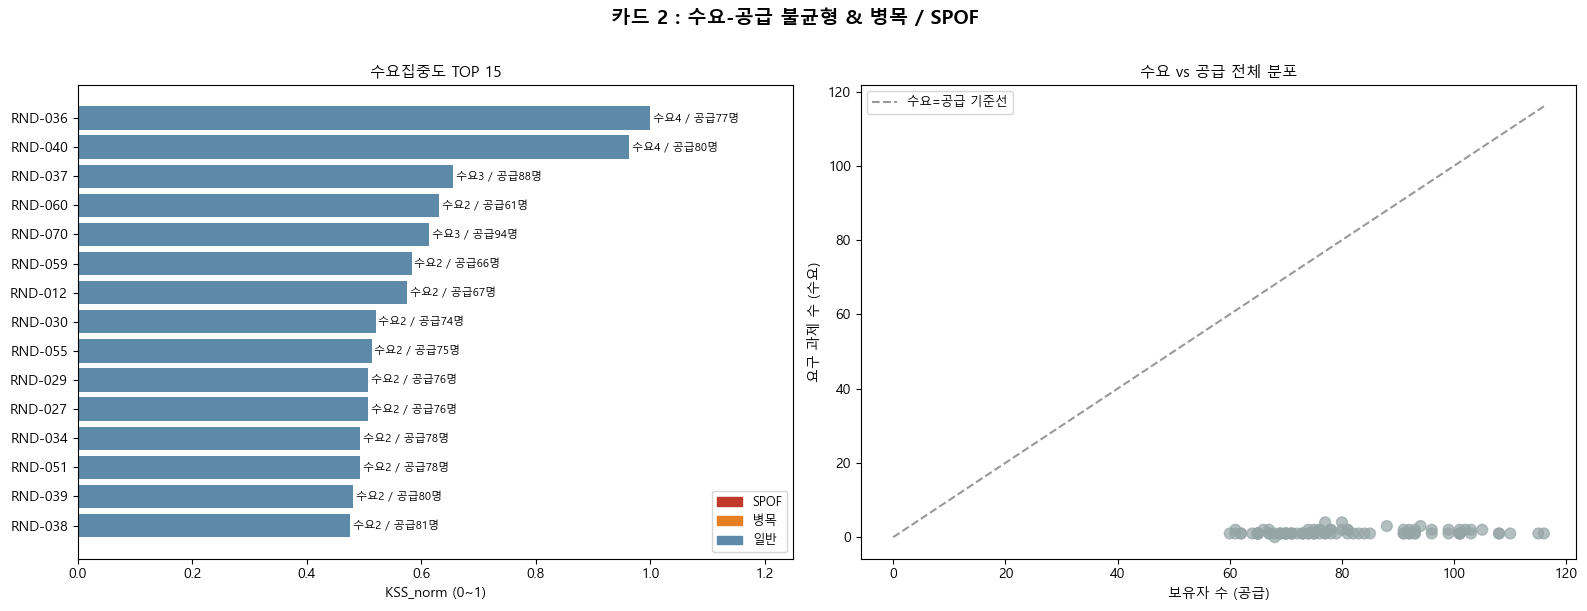


병목 스킬 : 0개 | SPOF 스킬 : 0개


In [7]:
# ── KSS 계산 ──────────────────────────────────────────────────────────────
kss_raw = demand / (holders.reindex(ALL_SKILLS).fillna(0) + 1e-9)
kss_min, kss_max = kss_raw.min(), kss_raw.max()
kss_norm = (kss_raw - kss_min) / (kss_max - kss_min)

df_kss = pd.DataFrame({
    '스킬': ALL_SKILLS,
    '요구과제수': demand.reindex(ALL_SKILLS).fillna(0).astype(int),
    '보유자수': holders.reindex(ALL_SKILLS).fillna(0).astype(int),
    'KSS_raw': kss_raw.reindex(ALL_SKILLS),
    'KSS_norm': kss_norm.reindex(ALL_SKILLS)
}).sort_values('KSS_norm', ascending=False).reset_index(drop=True)

# 병목 : 보유자 수 < 요구 과제 수
df_kss['병목'] = df_kss['보유자수'] < df_kss['요구과제수']

# SPOF : 보유율 하위 5% AND 요구 과제 1개 이상
threshold_5pct = N_PEOPLE * 0.05
df_kss['SPOF'] = (df_kss['보유자수'] <= threshold_5pct) & (df_kss['요구과제수'] >= 1)

# ── 시각화 ────────────────────────────────────────────────────────────────
TOP_N = 15
top_kss    = df_kss.head(TOP_N)
spof_df    = df_kss[df_kss['SPOF']].head(TOP_N)
bottleneck = df_kss[df_kss['병목']]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('카드 2 : 수요-공급 불균형 & 병목 / SPOF', fontsize=14, fontweight='bold', y=1.01)

# 왼쪽: KSS TOP 15
bar_colors = ['#C0392B' if r['SPOF'] else ('#E67E22' if r['병목'] else '#5D8AA8')
              for _, r in top_kss.iterrows()]
bars = axes[0].barh(top_kss['스킬'], top_kss['KSS_norm'], color=bar_colors)
for bar, row in zip(bars, top_kss.itertuples()):
    axes[0].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                 f'수요{row.요구과제수} / 공급{row.보유자수}명',
                 va='center', fontsize=8)
axes[0].set_xlim(0, 1.25)
axes[0].set_xlabel('KSS_norm (0~1)')
axes[0].set_title(f'수요집중도 TOP {TOP_N}', fontsize=11)
axes[0].invert_yaxis()
spof_patch = mpatches.Patch(color='#C0392B', label='SPOF')
btl_patch  = mpatches.Patch(color='#E67E22', label='병목')
nor_patch  = mpatches.Patch(color='#5D8AA8', label='일반')
axes[0].legend(handles=[spof_patch, btl_patch, nor_patch], fontsize=9)

# 오른쪽: 수요 vs 공급 산점도 (전체)
colors_scatter = ['#C0392B' if r['SPOF'] else ('#E67E22' if r['병목'] else '#95A5A6')
                  for _, r in df_kss.iterrows()]
axes[1].scatter(df_kss['보유자수'], df_kss['요구과제수'], c=colors_scatter, alpha=0.7, s=60)
max_val = max(df_kss['보유자수'].max(), df_kss['요구과제수'].max())
axes[1].plot([0, max_val], [0, max_val], 'k--', alpha=0.4, label='수요=공급 기준선')
# SPOF 라벨
for _, r in df_kss[df_kss['SPOF']].iterrows():
    axes[1].annotate(r['스킬'], (r['보유자수'], r['요구과제수']),
                     fontsize=7, xytext=(4, 4), textcoords='offset points', color='#C0392B')
axes[1].set_xlabel('보유자 수 (공급)')
axes[1].set_ylabel('요구 과제 수 (수요)')
axes[1].set_title('수요 vs 공급 전체 분포', fontsize=11)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"\n병목 스킬 : {bottleneck.shape[0]}개 | SPOF 스킬 : {df_kss['SPOF'].sum()}개")
if df_kss['SPOF'].sum() > 0:
    print('⚠️  SPOF 스킬 목록:', df_kss[df_kss['SPOF']]['스킬'].tolist())

### 카드 2 선택 — 수요집중도를 적합도에 반영할 스킬 체크

In [17]:
skill_order_kss = df_kss['스킬'].tolist()

cb_kss = {}
rows_kss = []
for skill in skill_order_kss:
    row = df_kss[df_kss['스킬'] == skill].iloc[0]
    flag = '🔴SPOF' if row['SPOF'] else ('🟠병목' if row['병목'] else '')
    label = f"{skill}  │  KSS={row['KSS_norm']:.3f}  │  수요{row['요구과제수']}/공급{row['보유자수']}  {flag}"
    cb = widgets.Checkbox(value=False, description=label,
                          layout=widgets.Layout(width='580px'),
                          style={'description_width': 'initial'})
    cb_kss[skill] = cb
    rows_kss.append(cb)

btn_all_spof    = widgets.Button(description='SPOF 전체 선택',  button_style='danger',  layout=widgets.Layout(width='150px'))
btn_all_bottleneck = widgets.Button(description='병목 전체 선택', button_style='warning', layout=widgets.Layout(width='150px'))
btn_clear_kss   = widgets.Button(description='전체 해제',        button_style='',        layout=widgets.Layout(width='140px'))

def select_spof(_):
    for skill, cb in cb_kss.items():
        row = df_kss[df_kss['스킬'] == skill].iloc[0]
        cb.value = bool(row['SPOF'])

def select_bottleneck(_):
    for skill, cb in cb_kss.items():
        row = df_kss[df_kss['스킬'] == skill].iloc[0]
        cb.value = bool(row['병목'])

def clear_all_kss(_):
    for cb in cb_kss.values(): cb.value = False

btn_all_spof.on_click(select_spof)
btn_all_bottleneck.on_click(select_bottleneck)
btn_clear_kss.on_click(clear_all_kss)

header2 = widgets.HTML('<b>수요집중도를 적합도에 반영할 스킬을 선택하세요 (I_kss = 1)</b><br><br>')
btn_row2 = widgets.HBox([btn_all_spof, btn_all_bottleneck, btn_clear_kss])
scroll_box2 = widgets.VBox(rows_kss, layout=widgets.Layout(height='350px', overflow_y='scroll', border='1px solid #ccc', padding='6px'))

display(widgets.VBox([header2, btn_row2, scroll_box2]))

## 5. EDA — 카드 3 : 스킬 난이도

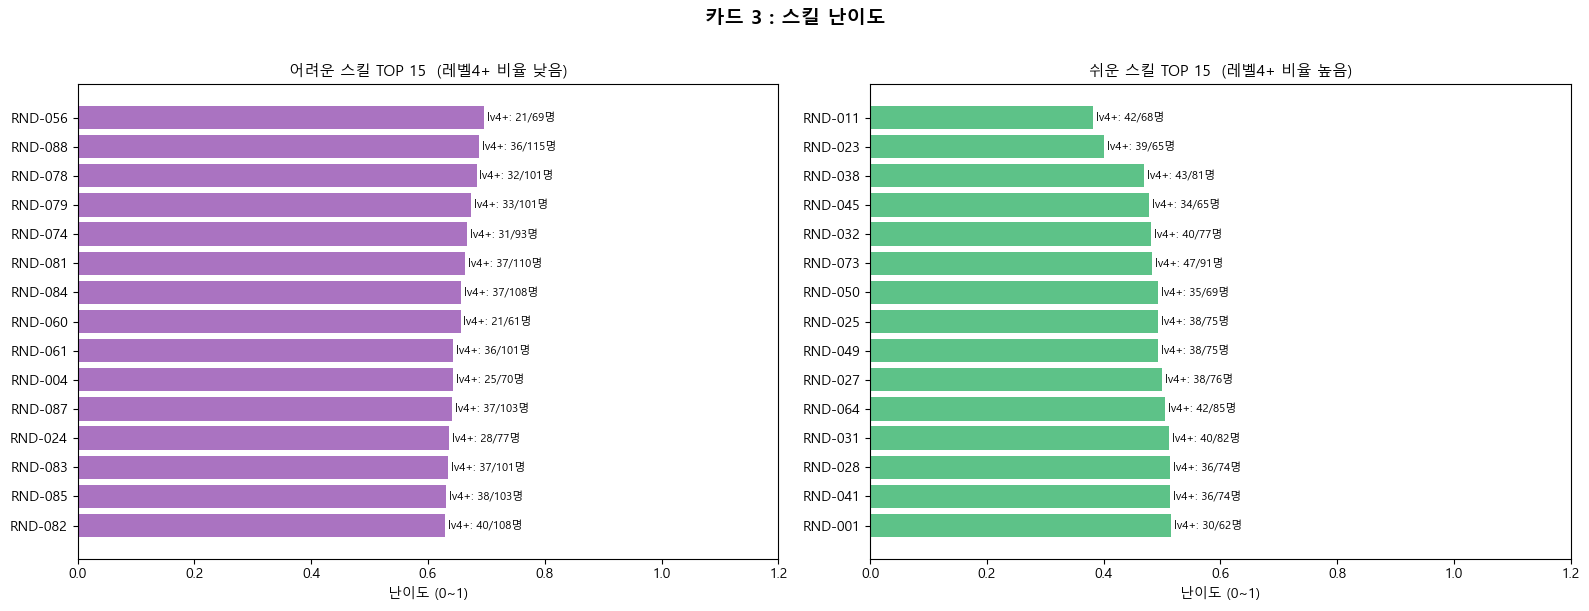

In [10]:
# ── 스킬 난이도 계산 ──────────────────────────────────────────────────────
# 난이도(s) = 1 - (레벨4이상 보유자 수 / 전체 보유자 수)
# 보유자가 0명인 스킬은 난이도 정의 불가 → 0으로 처리
difficulty_raw = pd.Series(index=ALL_SKILLS, dtype=float)
for s in ALL_SKILLS:
    h = holders.get(s, 0)
    h4 = holders_lv4.get(s, 0)
    difficulty_raw[s] = (1 - h4 / h) if h > 0 else 0.0

df_diff = pd.DataFrame({
    '스킬': ALL_SKILLS,
    '보유자수': holders.reindex(ALL_SKILLS).fillna(0).astype(int),
    '레벨4이상': holders_lv4.reindex(ALL_SKILLS).fillna(0).astype(int),
    '난이도': difficulty_raw
}).sort_values('난이도', ascending=False).reset_index(drop=True)

# ── 시각화 ────────────────────────────────────────────────────────────────
TOP_N = 15
top_hard = df_diff.head(TOP_N)
top_easy = df_diff.tail(TOP_N).iloc[::-1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('카드 3 : 스킬 난이도', fontsize=14, fontweight='bold', y=1.01)

for ax, df_sub, title, base_color in [
    (axes[0], top_hard, f'어려운 스킬 TOP {TOP_N}  (레벨4+ 비율 낮음)', '#8E44AD'),
    (axes[1], top_easy, f'쉬운 스킬 TOP {TOP_N}  (레벨4+ 비율 높음)',  '#27AE60'),
]:
    bars = ax.barh(df_sub['스킬'], df_sub['난이도'], color=base_color, alpha=0.75)
    for bar, row in zip(bars, df_sub.itertuples()):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f'lv4+: {row.레벨4이상}/{row.보유자수}명',
                va='center', fontsize=8)
    ax.set_xlim(0, 1.2)
    ax.set_xlabel('난이도 (0~1)')
    ax.set_title(title, fontsize=11)
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

### 카드 3 선택 — 과제 난이도 계산에 포함할 스킬 체크

In [18]:
skill_order_diff = df_diff['스킬'].tolist()

cb_diff = {}
rows_diff = []
for skill in skill_order_diff:
    row = df_diff[df_diff['스킬'] == skill].iloc[0]
    label = f"{skill}  │  난이도={row['난이도']:.3f}  │  lv4+: {row['레벨4이상']}/{row['보유자수']}명"
    cb = widgets.Checkbox(value=False, description=label,
                          layout=widgets.Layout(width='530px'),
                          style={'description_width': 'initial'})
    cb_diff[skill] = cb
    rows_diff.append(cb)

btn_top20_diff = widgets.Button(description='어려운 스킬 TOP20 선택', button_style='warning', layout=widgets.Layout(width='200px'))
btn_clear_diff = widgets.Button(description='전체 해제',              button_style='',        layout=widgets.Layout(width='140px'))

def select_top20_diff(_):
    top20 = set(df_diff.head(20)['스킬'].tolist())
    for skill, cb in cb_diff.items():
        cb.value = skill in top20

def clear_all_diff(_):
    for cb in cb_diff.values(): cb.value = False

btn_top20_diff.on_click(select_top20_diff)
btn_clear_diff.on_click(clear_all_diff)

header3 = widgets.HTML('<b>과제 난이도 계산에 포함할 스킬을 선택하세요 (카드 3)</b><br><br>')
btn_row3 = widgets.HBox([btn_top20_diff, btn_clear_diff])
scroll_box3 = widgets.VBox(rows_diff, layout=widgets.Layout(height='350px', overflow_y='scroll', border='1px solid #ccc', padding='6px'))

display(widgets.VBox([header3, btn_row3, scroll_box3]))

## 6. EDA — 카드 4 : 인재 유형 분류 (인사이트 전용)

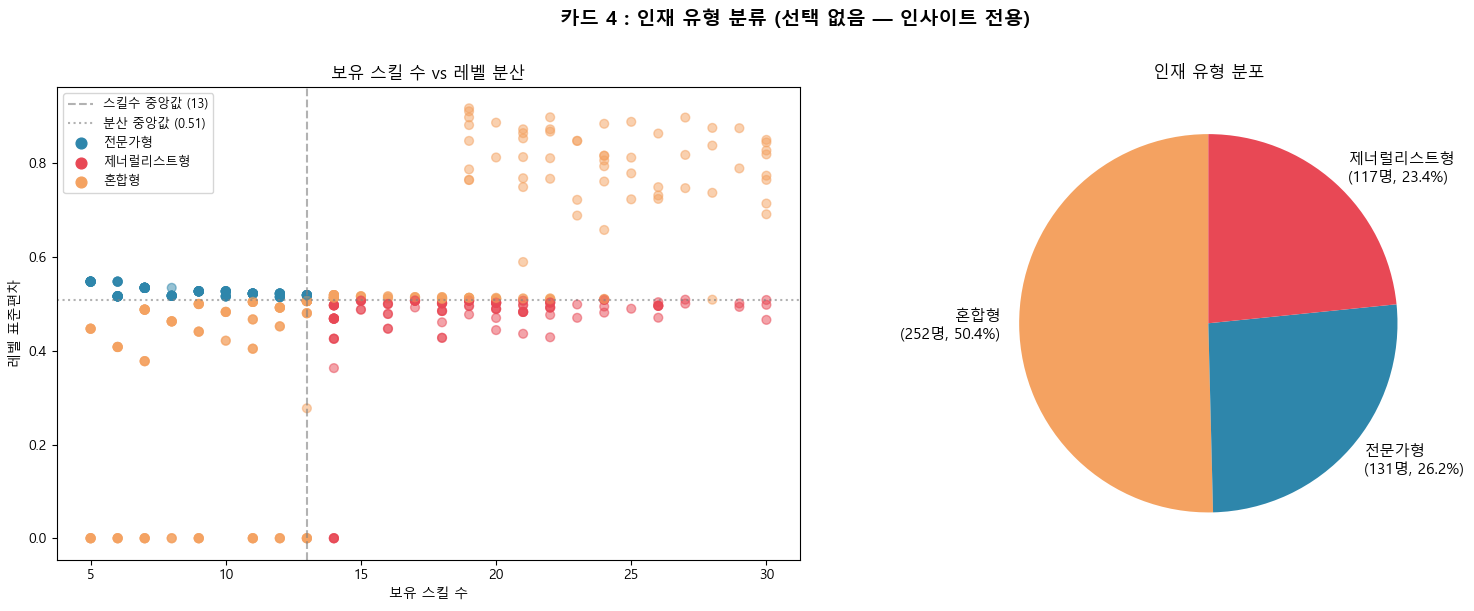


[유형별 평균 스킬 현황]
         보유스킬수  평균레벨  레벨분산
유형                        
전문가형      8.82  2.22  0.53
제너럴리스트형  19.12  3.58  0.47
혼합형      14.81  2.75  0.49


In [13]:
# ── 인재 유형 분류 ────────────────────────────────────────────────────────
# 전문가형 : 보유 스킬 수 적고 레벨 분산 큼
# 제너럴리스트형 : 보유 스킬 수 많고 레벨 분산 작음

talent_rows = []
for emp_id, row in df_wide.iterrows():
    skills_held = row[row > 0]
    n_skills = len(skills_held)
    avg_level = skills_held.mean() if n_skills > 0 else 0
    std_level = skills_held.std()  if n_skills > 1 else 0
    talent_rows.append({'사번': emp_id, '보유스킬수': n_skills,
                        '평균레벨': avg_level, '레벨분산': std_level})

df_talent = pd.DataFrame(talent_rows)

# 분류 기준 : 스킬 수 중앙값, 분산 중앙값
med_skills = df_talent['보유스킬수'].median()
med_std    = df_talent['레벨분산'].median()

def classify_talent(r):
    if r['보유스킬수'] <= med_skills and r['레벨분산'] >= med_std:
        return '전문가형'
    elif r['보유스킬수'] > med_skills and r['레벨분산'] < med_std:
        return '제너럴리스트형'
    else:
        return '혼합형'

df_talent['유형'] = df_talent.apply(classify_talent, axis=1)

# ── 시각화 ────────────────────────────────────────────────────────────────
type_colors = {'전문가형': '#2E86AB', '제너럴리스트형': '#E84855', '혼합형': '#F4A261'}
colors_scatter = [type_colors[t] for t in df_talent['유형']]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('카드 4 : 인재 유형 분류 (선택 없음 — 인사이트 전용)', fontsize=14, fontweight='bold', y=1.01)

# 왼쪽: 산점도
axes[0].scatter(df_talent['보유스킬수'], df_talent['레벨분산'], c=colors_scatter, alpha=0.5, s=40)
axes[0].axvline(med_skills, color='gray', linestyle='--', alpha=0.6, label=f'스킬수 중앙값 ({med_skills:.0f})')
axes[0].axhline(med_std,    color='gray', linestyle=':',  alpha=0.6, label=f'분산 중앙값 ({med_std:.2f})')
axes[0].set_xlabel('보유 스킬 수')
axes[0].set_ylabel('레벨 표준편차')
axes[0].set_title('보유 스킬 수 vs 레벨 분산')
for t, c in type_colors.items():
    axes[0].scatter([], [], c=c, label=t, s=60)
axes[0].legend(fontsize=9)

# 오른쪽: 유형별 비율 파이차트
type_counts = df_talent['유형'].value_counts()
axes[1].pie(type_counts.values,
            labels=[f"{k}\n({v}명, {v/len(df_talent)*100:.1f}%)" for k, v in type_counts.items()],
            colors=[type_colors[k] for k in type_counts.index],
            autopct='', startangle=90, textprops={'fontsize': 11})
axes[1].set_title('인재 유형 분포')

plt.tight_layout()
plt.show()

print('\n[유형별 평균 스킬 현황]')
print(df_talent.groupby('유형')[['보유스킬수','평균레벨','레벨분산']].mean().round(2))

## 7. 과제 난이도 계산 & 적합도 매트릭스 산출
> **위 카드 1·2·3 체크박스 선택을 완료한 후 이 셀을 실행하세요.**

In [20]:
# ── 7-1. 선택 결과 수집 ───────────────────────────────────────────────────
selected_idf  = [s for s, cb in cb_idf.items()  if cb.value]   # 카드 1
selected_kss  = [s for s, cb in cb_kss.items()  if cb.value]   # 카드 2
selected_diff = [s for s, cb in cb_diff.items() if cb.value]   # 카드 3

print(f'카드 1 (희귀도 반영) 선택 스킬     : {len(selected_idf)}개')
print(f'카드 2 (수요집중도 반영) 선택 스킬  : {len(selected_kss)}개')
print(f'카드 3 (과제 난이도 계산) 선택 스킬 : {len(selected_diff)}개')

# ── 7-2. 과제 난이도 계산 ────────────────────────────────────────────────
# 과제난이도(p) = Σ 스킬난이도(s)  (카드3 선택 스킬 중 해당 과제 필수 스킬)
proj_difficulty = {}
for proj in ALL_PROJECTS:
    if proj not in proj_skill_bin.columns:
        proj_difficulty[proj] = 0.0
        continue
    required_skills = proj_skill_bin.index[proj_skill_bin[proj] == 1].tolist()
    selected_and_required = [s for s in selected_diff if s in required_skills]
    proj_difficulty[proj] = sum(difficulty_raw.get(s, 0) for s in selected_and_required)

max_diff = max(proj_difficulty.values()) if proj_difficulty else 1
proj_difficulty_norm = {
    p: (v / max_diff if max_diff > 0 else 0) for p, v in proj_difficulty.items()
}

print('\n[과제 난이도 (정규화)]')
diff_df = pd.DataFrame({'과제': list(proj_difficulty_norm.keys()),
                        '난이도_norm': list(proj_difficulty_norm.values())})
diff_df = diff_df.sort_values('난이도_norm', ascending=False)
print(diff_df.to_string(index=False))

카드 1 (희귀도 반영) 선택 스킬     : 6개
카드 2 (수요집중도 반영) 선택 스킬  : 6개
카드 3 (과제 난이도 계산) 선택 스킬 : 6개

[과제 난이도 (정규화)]
 과제  난이도_norm
P17  1.000000
P20  0.997927
P11  0.512853
P16  0.491484
P18  0.489250
P04  0.000000
P13  0.000000
P19  0.000000
P03  0.000000
P15  0.000000
P14  0.000000
P12  0.000000
P05  0.000000
P02  0.000000
P10  0.000000
P09  0.000000
P08  0.000000
P07  0.000000
P06  0.000000
P01  0.000000


In [21]:
# ── 7-3. 스킬 중요도 계산 ─────────────────────────────────────────────────
# 스킬중요도(s) = 1 + I_idf × IDF_norm(s) + I_kss × KSS_norm(s)
skill_importance = {}
for s in ALL_SKILLS:
    i_idf = 1 if s in selected_idf else 0
    i_kss = 1 if s in selected_kss else 0
    idf_v = idf_norm.get(s, 0)
    kss_v = kss_norm.get(s, 0) if isinstance(kss_norm, pd.Series) else kss_norm.reindex([s]).iloc[0]
    skill_importance[s] = 1 + i_idf * idf_v + i_kss * kss_v

# ── 7-4. 개인별 적합도 매트릭스 계산 ─────────────────────────────────────
# Fit(사람, 과제) = Σ [레벨(s) × 스킬중요도(s)] × (1 + 0.5 × 과제난이도_norm(p))
# 과제 필수 스킬에 포함된 스킬만 합산

W3 = 0.5
fit_matrix = pd.DataFrame(index=df_wide.index, columns=ALL_PROJECTS, dtype=float)

for proj in ALL_PROJECTS:
    if proj not in proj_skill_bin.columns:
        fit_matrix[proj] = 0.0
        continue
    required_skills = proj_skill_bin.index[proj_skill_bin[proj] == 1].tolist()
    req_in_wide = [s for s in required_skills if s in df_wide.columns]
    importance = np.array([skill_importance[s] for s in req_in_wide])
    levels = df_wide[req_in_wide].values  # (N_people × N_req_skills)
    base_fit = (levels * importance).sum(axis=1)
    diff_bonus = 1 + W3 * proj_difficulty_norm[proj]
    fit_matrix[proj] = base_fit * diff_bonus

print(f'적합도 매트릭스 생성 완료: {fit_matrix.shape[0]}명 × {fit_matrix.shape[1]}과제')
print(f'\n[과제별 적합도 통계]')
stats = fit_matrix.agg(['max','min','mean','std']).T.round(2)
stats['max-min'] = stats['max'] - stats['min']
print(stats.sort_values('max-min', ascending=False).to_string())

적합도 매트릭스 생성 완료: 500명 × 20과제

[과제별 적합도 통계]
       max  min  mean   std  max-min
P12  40.95  0.0  4.04  5.99    40.95
P01  40.63  0.0  3.75  6.75    40.63
P17  39.11  0.0  6.72  7.82    39.11
P11  37.59  0.0  3.68  5.78    37.59
P07  37.28  0.0  4.14  6.64    37.28
P16  37.19  0.0  5.09  7.31    37.19
P02  36.61  0.0  3.34  5.80    36.61
P15  36.10  0.0  4.79  6.12    36.10
P08  34.20  0.0  4.70  6.83    34.20
P09  33.00  0.0  3.25  5.53    33.00
P06  31.85  0.0  3.65  6.00    31.85
P18  30.88  0.0  4.49  6.37    30.88
P10  27.00  0.0  2.87  4.48    27.00
P20  26.98  0.0  5.01  5.78    26.98
P04  26.75  0.0  3.27  4.84    26.75
P05  26.00  0.0  3.05  4.88    26.00
P03  26.00  0.0  3.15  4.34    26.00
P14  23.63  0.0  3.25  4.20    23.63
P13  23.00  0.0  2.96  4.49    23.00
P19  20.00  0.0  2.99  3.93    20.00


## 8. 결과 시각화

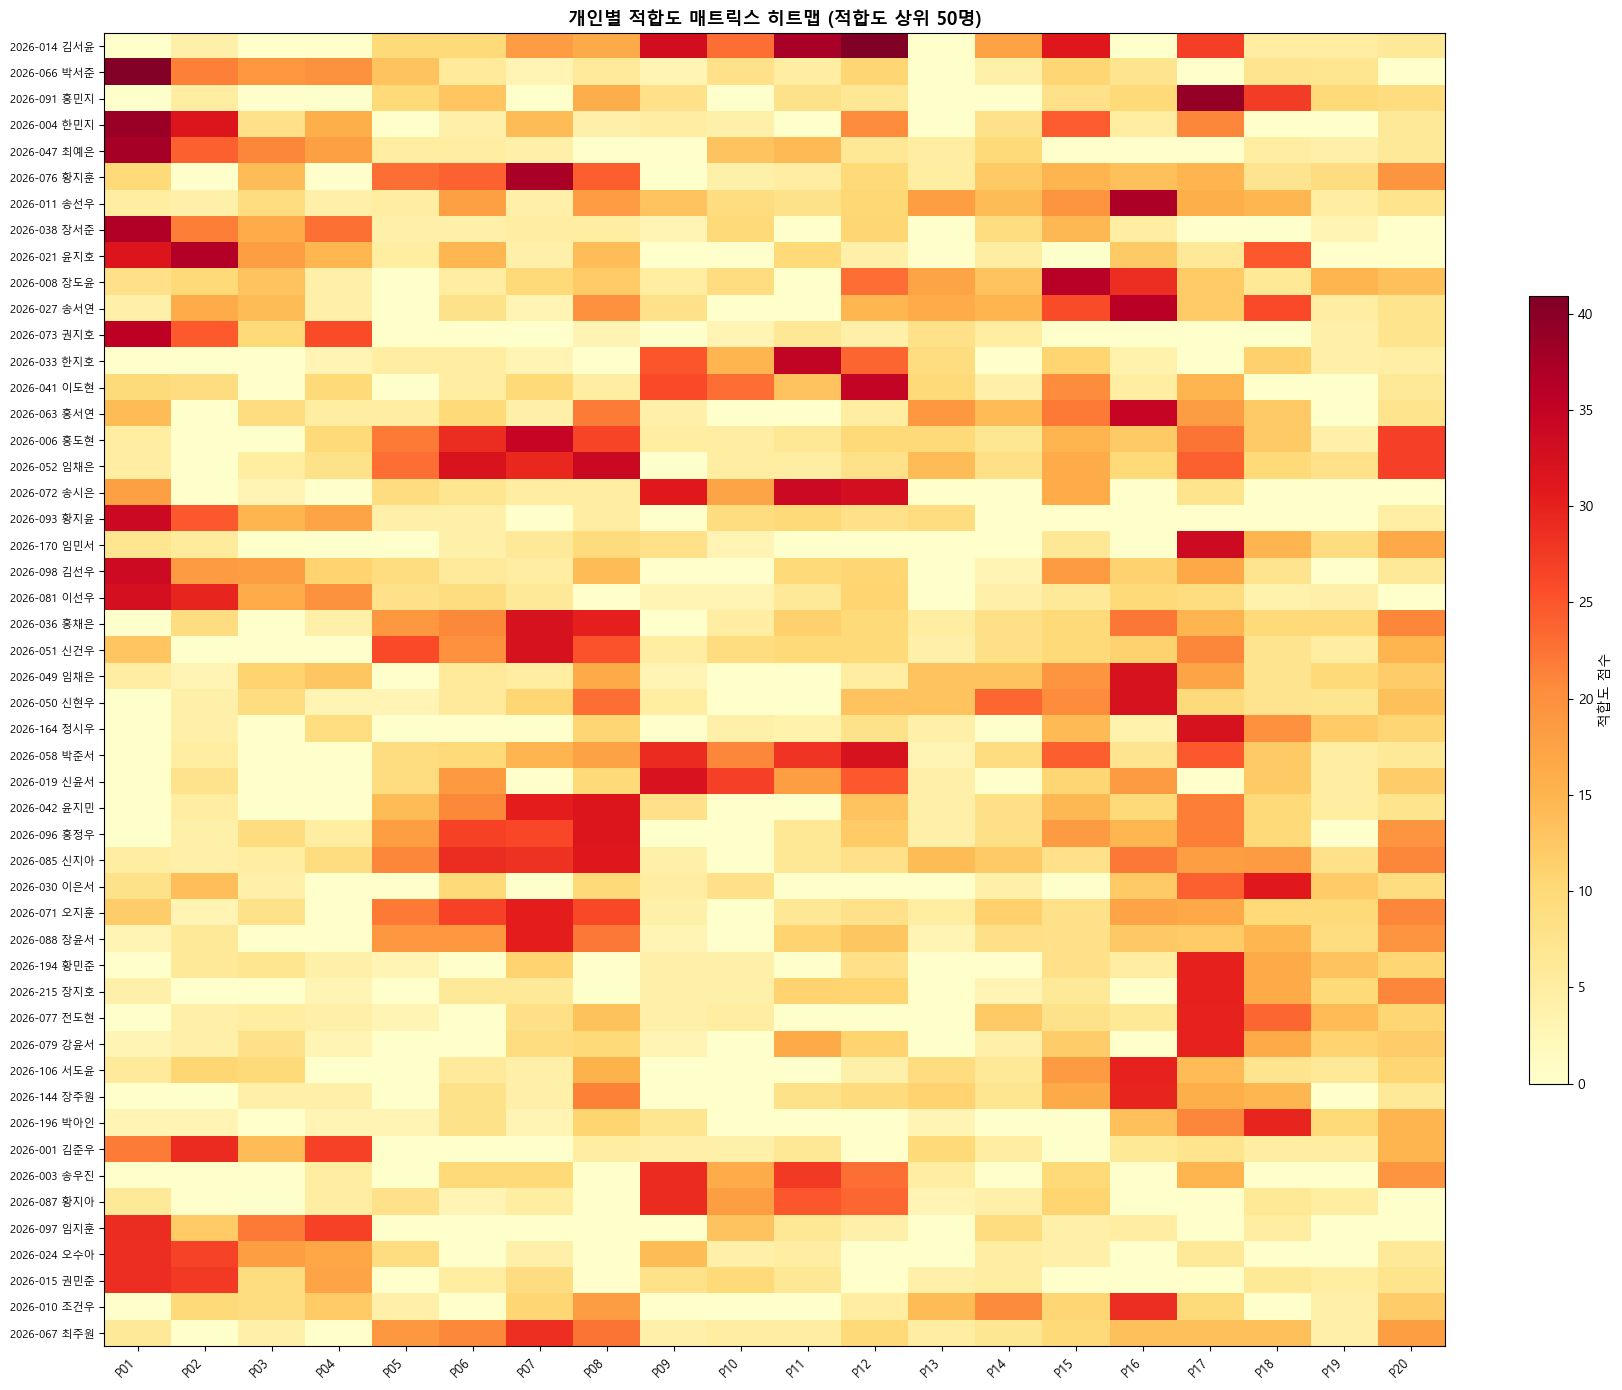

In [22]:
# ── 8-1. 적합도 히트맵 (상위 50명 × 전체 과제) ───────────────────────────
top50_idx = fit_matrix.max(axis=1).nlargest(50).index
heatmap_data = fit_matrix.loc[top50_idx]

fig, ax = plt.subplots(figsize=(18, 14))
im = ax.imshow(heatmap_data.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(ALL_PROJECTS)))
ax.set_xticklabels(ALL_PROJECTS, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(top50_idx)))

# 사번 → 성명 매핑
id_to_name = df_hr.set_index('사번').apply(lambda r: f"{r['Last Name']}{r['First Name']}", axis=1).to_dict()
yticklabels = [f"{idx} {id_to_name.get(idx,'')}" for idx in top50_idx]
ax.set_yticklabels(yticklabels, fontsize=8)
plt.colorbar(im, ax=ax, shrink=0.6, label='적합도 점수')
ax.set_title('개인별 적합도 매트릭스 히트맵 (적합도 상위 50명)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [23]:
# ── 8-2. 과제별 TOP5 후보 ─────────────────────────────────────────────────
print('=' * 60)
print('과제별 적합도 TOP 5 후보')
print('=' * 60)
for proj in ALL_PROJECTS:
    top5 = fit_matrix[proj].nlargest(5)
    names = [f"{idx}({id_to_name.get(idx,'')})={score:.1f}" for idx, score in top5.items()]
    print(f"{proj}: {' | '.join(names)}")

과제별 적합도 TOP 5 후보
P01: 2026-066(박서준)=40.6 | 2026-004(한민지)=38.6 | 2026-047(최예은)=37.6 | 2026-038(장서준)=36.7 | 2026-073(권지호)=35.6
P02: 2026-021(윤지호)=36.6 | 2026-004(한민지)=31.5 | 2026-081(이선우)=29.7 | 2026-001(김준우)=29.0 | 2026-015(권민준)=27.5
P03: 2026-089(강준서)=26.0 | 2026-097(임지훈)=22.0 | 2026-047(최예은)=21.0 | 2026-066(박서준)=19.0 | 2026-021(윤지호)=18.0
P04: 2026-001(김준우)=26.8 | 2026-097(임지훈)=26.8 | 2026-020(안지훈)=25.8 | 2026-073(권지호)=25.8 | 2026-009(송채원)=22.8
P05: 2026-051(신건우)=26.0 | 2026-052(임채은)=23.0 | 2026-076(황지훈)=23.0 | 2026-006(홍도현)=22.0 | 2026-071(오지훈)=22.0
P06: 2026-052(임채은)=31.9 | 2026-006(홍도현)=28.8 | 2026-085(신지아)=28.8 | 2026-199(임선우)=27.9 | 2026-071(오지훈)=26.9
P07: 2026-076(황지훈)=37.3 | 2026-006(홍도현)=34.6 | 2026-036(홍채은)=32.3 | 2026-051(신건우)=32.3 | 2026-042(윤지민)=30.3
P08: 2026-052(임채은)=34.2 | 2026-042(윤지민)=31.6 | 2026-096(홍정우)=31.6 | 2026-085(신지아)=31.1 | 2026-036(홍채은)=30.1
P09: 2026-014(김서윤)=33.0 | 2026-019(신윤서)=32.0 | 2026-072(송시은)=31.0 | 2026-003(송우진)=29.0 | 2026-058(박준서)=29.0
P10: 2026-0

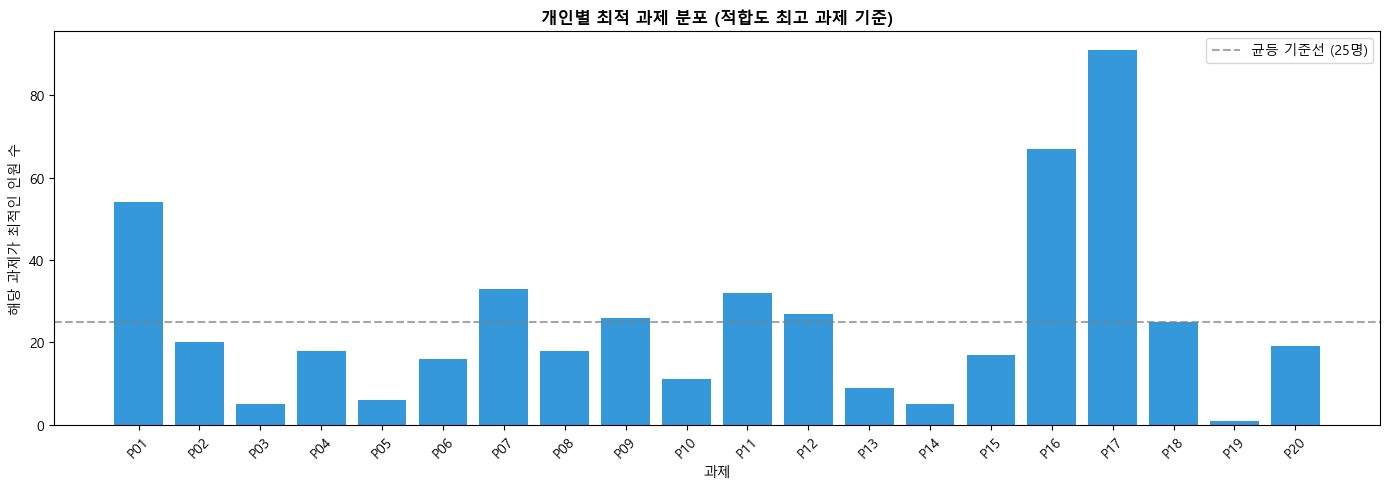

In [24]:
# ── 8-3. 개인별 최적 과제 분포 ───────────────────────────────────────────
best_proj = fit_matrix.idxmax(axis=1)
best_dist = best_proj.value_counts().reindex(ALL_PROJECTS, fill_value=0)

fig, ax = plt.subplots(figsize=(14, 5))
colors_bar = ['#E74C3C' if v == 0 else '#3498DB' for v in best_dist.values]
ax.bar(best_dist.index, best_dist.values, color=colors_bar)
ax.set_xlabel('과제')
ax.set_ylabel('해당 과제가 최적인 인원 수')
ax.set_title('개인별 최적 과제 분포 (적합도 최고 과제 기준)', fontsize=12, fontweight='bold')
ax.axhline(len(df_wide) / len(ALL_PROJECTS), color='gray', linestyle='--',
           alpha=0.7, label=f'균등 기준선 ({len(df_wide)/len(ALL_PROJECTS):.0f}명)')
for i, v in enumerate(best_dist.values):
    if v == 0:
        ax.text(i, 0.5, '0', ha='center', fontsize=8, color='red')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

zero_proj = best_dist[best_dist == 0].index.tolist()
if zero_proj:
    print(f'⚠️  최적 후보가 0명인 과제: {zero_proj}')

## 9. 최종 매트릭스 확인

In [25]:
# 최종 적합도 매트릭스 미리보기 (상위 10명)
display(fit_matrix.head(10).round(2))
print(f'\n전체 shape: {fit_matrix.shape}')
print(f'전체 평균 적합도: {fit_matrix.values.mean():.2f}')
print(f'전체 최고 적합도: {fit_matrix.values.max():.2f}')
print('\n✅ fit_matrix 변수에 전체 적합도 매트릭스가 저장되어 있습니다.')
print('   다음 단계(배치 알고리즘)에서 이 매트릭스를 입력으로 사용하세요.')

,P01,P02,P03,P04,P05,P06,P07,P08,P09,P10,P11,P12,P13,P14,P15,P16,P17,P18,P19,P20
사번,,,,,,,,,,,,,,,,,,,,
2026-001,21.90,29.00,14.0,26.75,0.0,0.00,0.00,5.00,4.0,4.0,6.28,0.00,10.0,5.00,0.00,6.23,7.50,4.98,5.0,14.99
2026-002,11.80,10.00,5.0,4.00,8.0,0.00,0.00,0.00,4.0,9.0,0.00,4.00,4.0,5.00,0.00,4.98,28.50,21.16,18.0,11.99
2026-003,0.00,0.00,0.0,5.00,0.0,10.00,10.00,0.00,29.0,16.0,27.54,22.92,5.0,0.00,10.00,0.00,15.00,0.00,0.0,19.49
2026-004,38.63,31.51,8.0,15.80,0.0,4.00,14.00,4.00,5.0,4.0,0.00,20.42,0.0,8.00,24.42,4.98,21.00,0.00,0.0,6.00
2026-005,21.80,19.51,14.0,17.00,10.0,5.00,0.00,0.00,0.0,10.0,16.23,11.92,0.0,0.00,0.00,0.00,6.00,0.00,5.0,0.00
2026-006,5.00,0.00,0.0,10.00,22.0,28.81,34.63,26.44,5.0,5.0,6.28,10.00,10.0,6.63,15.00,12.22,22.50,12.21,4.0,26.98
2026-007,0.00,0.00,0.0,0.00,5.0,4.00,8.28,8.28,18.0,19.0,21.36,0.00,0.0,13.28,5.00,0.00,15.00,0.00,0.0,0.00
2026-008,8.00,10.00,13.0,4.00,0.0,5.00,10.00,12.07,5.0,9.0,0.00,23.03,17.0,13.00,36.10,28.65,12.11,6.22,15.0,13.49
2026-009,24.63,20.61,14.0,22.75,0.0,5.00,0.00,8.00,4.0,10.0,0.00,0.00,8.0,4.00,0.00,17.44,0.00,0.00,5.0,7.49



전체 shape: (500, 20)
전체 평균 적합도: 3.91
전체 최고 적합도: 40.95

✅ fit_matrix 변수에 전체 적합도 매트릭스가 저장되어 있습니다.
   다음 단계(배치 알고리즘)에서 이 매트릭스를 입력으로 사용하세요.
